# Revision: 6-31G(d) vs 6-31+G(d) TS bond lengths

This notebook prepares the basis-set sensitivity calculation requested during revision and analyzes the resulting transition-state geometries. It uses the 15 benchmark TS structures in `Benchmark_new/OPT`, changes **only** `6-31G(d)` to `6-31+G(d)`, and compares the forming B–Cl distance, breaking C–Cl distance, and reactive B–Cl–C angle.

Success criteria:

- one validated `6-31+G(d)` Gaussian input per benchmark TS;
- normal termination and exactly one imaginary frequency for every new TS;
- signed and absolute B–Cl/C–Cl distance changes, B–Cl–C angle changes, and whole-structure RMSD trends exported as reviewer-ready tables and figures.


## 1. Setup and paths

Raw Gaussian files remain in the external benchmark workspace. Tables and figures are written to the repository's `output/revision_basis_set_geometry` folder. Override `BORYLXAT_RAW_CALC_ROOT` before running if the raw calculation root is elsewhere.


In [20]:
from __future__ import annotations

import re, glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from DFTStructureGenerator.FormatConverter import read_gjf
from DFTStructureGenerator.logfile_process import Logfile
from DFTStructureGenerator.project_paths import raw_calc_path

BENCHMARK_DIR = raw_calc_path("Benchmark_new")
SOURCE_DIR = BENCHMARK_DIR / "OPT"
PLUS_BASIS_DIR = BENCHMARK_DIR / "OPT_6-31plusGd"
ENG_BASIS_DIR = BENCHMARK_DIR / "ENG_6-31plusGd"
RESULT_DIR = Path("output") / "revision_basis_set_geometry"

SPE_METHOD = "wb97xd/6-311+g(d,p) scrf=(smd,solvent=toluene) nosymm"

NPROC_SHARED = 32
MEMORY = "100GB"
OVERWRITE_INPUTS = True
EXPECTED_REACTIVE_SYMBOLS = ["B", "Cl", "C"]

if not SOURCE_DIR.is_dir():
    raise FileNotFoundError(f"Benchmark OPT directory not found: {SOURCE_DIR}")
PLUS_BASIS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"6-31G(d) source: {SOURCE_DIR}")
print(f"6-31+G(d) jobs:  {PLUS_BASIS_DIR}")
print(f"Analysis output: {RESULT_DIR.resolve()}")


6-31G(d) source: E:\work\B_Cl_Nu\Benchmark_new\OPT
6-31+G(d) jobs:  E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd
Analysis output: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\revision_basis_set_geometry


## 2. Read and validate the 6-31G(d) benchmark TS structures

The Gaussian title stores the reactive B–Cl–C atom numbers (1-based). The explicit symbol check below prevents accidental measurement of a spectator chlorine or an unrelated carbon. Final optimized coordinates are taken from the last geometry in each normally terminated log.


In [21]:
def distance(positions, atom_i, atom_j):
    return float(np.linalg.norm(positions[atom_i] - positions[atom_j]))


def angle_deg(positions, atom_i, atom_j, atom_k):
    vec_ij = positions[atom_i] - positions[atom_j]
    vec_kj = positions[atom_k] - positions[atom_j]
    cosine = np.dot(vec_ij, vec_kj) / (np.linalg.norm(vec_ij) * np.linalg.norm(vec_kj))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))


def aligned_rmsd(reference_positions, target_positions):
    # Kabsch alignment removes rigid-body translation/rotation before RMSD evaluation.
    reference = np.asarray(reference_positions, dtype=float)
    target = np.asarray(target_positions, dtype=float)
    if reference.shape != target.shape:
        raise ValueError(f"Shape mismatch for RMSD: {reference.shape} vs {target.shape}")

    reference_centered = reference - reference.mean(axis=0)
    target_centered = target - target.mean(axis=0)
    covariance = target_centered.T @ reference_centered
    left, _, right_t = np.linalg.svd(covariance)
    correction = np.eye(3)
    correction[-1, -1] = np.sign(np.linalg.det(left @ right_t))
    rotation = left @ correction @ right_t
    target_aligned = target_centered @ rotation
    delta = target_aligned - reference_centered
    return float(np.sqrt(np.mean(np.sum(delta * delta, axis=1))))


def load_ts_record(log_path):
    parsed = Logfile(
        str(log_path),
        read_title=True,
        freq_warning=True,
        ignore_print=True,
    )
    if not parsed.normal_end:
        raise ValueError(f"Not normally terminated: {log_path.name}")
    if parsed.running_positions is None or len(parsed.running_positions) == 0:
        raise ValueError(f"No optimized coordinates: {log_path.name}")
    if not isinstance(parsed.title, list) or len(parsed.title) < 3:
        raise ValueError(f"Reactive atom indices missing from title: {log_path.name}")

    reactive_indices = [int(value) - 1 for value in parsed.title[:3]]
    reactive_symbols = [parsed.symbol_list[index] for index in reactive_indices]
    if reactive_symbols != EXPECTED_REACTIVE_SYMBOLS:
        raise ValueError(
            f"Expected B-Cl-C at {parsed.title[:3]} in {log_path.name}; "
            f"found {reactive_symbols}"
        )

    positions = np.asarray(parsed.running_positions[-1], dtype=float)
    b_idx, cl_idx, c_idx = reactive_indices
    return {
        "name": log_path.stem,
        "source_log": log_path,
        "parsed": parsed,
        "symbols": list(parsed.symbol_list),
        "positions_631gd": positions,
        "reactive_indices": reactive_indices,
        "B_atom_1based": b_idx + 1,
        "Cl_atom_1based": cl_idx + 1,
        "C_atom_1based": c_idx + 1,
        "charge": parsed.charge,
        "multiplicity": parsed.multiplicity,
        "imaginary_frequency_count_631gd": parsed.unreal_freq,
        "route_631gd": parsed.method,
        "B_Cl_631gd_A": distance(positions, b_idx, cl_idx),
        "C_Cl_631gd_A": distance(positions, c_idx, cl_idx),
        "B_Cl_C_angle_631gd_deg": angle_deg(positions, b_idx, cl_idx, c_idx),
    }


source_logs = sorted(SOURCE_DIR.glob("B_*_L_*_Cl_*.log"))
source_records = [load_ts_record(path) for path in source_logs]
if not source_records:
    raise RuntimeError(f"No benchmark TS logs found in {SOURCE_DIR}")

baseline_columns = [
    "name", "B_atom_1based", "Cl_atom_1based", "C_atom_1based",
    "charge", "multiplicity", "imaginary_frequency_count_631gd",
    "B_Cl_631gd_A", "C_Cl_631gd_A", "B_Cl_C_angle_631gd_deg", "route_631gd",
]
baseline_df = pd.DataFrame(
    [{column: record[column] for column in baseline_columns} for record in source_records]
)
baseline_df.to_csv(RESULT_DIR / "baseline_631gd_bond_lengths.csv", index=False)

print(f"Validated {len(source_records)} benchmark transition states.")
display(baseline_df)


Validated 15 benchmark transition states.


,name,B_atom_1based,Cl_atom_1based,C_atom_1based,charge,multiplicity,imaginary_frequency_count_631gd,B_Cl_631gd_A,C_Cl_631gd_A,B_Cl_C_angle_631gd_deg,route_631gd
0,B_00388_L_00001_Cl_00475,1,2,19,0,2,1,2.588579,1.931784,177.740594,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
1,B_00388_L_00001_Cl_00477,1,2,18,0,2,1,2.593617,1.901643,178.395614,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
2,B_00388_L_00001_Cl_00490,1,2,19,0,2,1,2.607303,1.878886,177.678143,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
3,B_00388_L_00001_Cl_00506,1,2,19,0,2,1,2.842014,1.969860,176.260013,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
4,B_00388_L_00001_Cl_00519,1,2,18,0,2,1,2.761061,1.948254,176.182226,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
5,B_00388_L_00069_Cl_00490,1,2,19,0,2,1,2.403261,1.981529,177.835971,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
6,B_00388_L_00072_Cl_00490,1,2,37,0,2,1,2.412665,1.973693,175.561687,"opt=(calcfc,ts,noeigen,maxcycles=100) freq b3l..."
7,B_00388_L_00072_Cl_00519,1,2,36,0,2,1,2.518103,2.050808,179.029223,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
8,B_00391_L_00033_Cl_00477,1,4,27,0,2,1,2.411831,2.003671,174.689967,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
9,B_00391_L_00033_Cl_00519,1,4,27,0,2,1,2.571729,2.063907,174.545644,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."


## 3. Generate 6-31+G(d) Gaussian inputs

The original route is reused verbatim except for the basis-set substitution. This preserves each structure's original `maxcycles` value and all other model chemistry. Gaussian will use the open-shell form for these neutral doublets; the charge and multiplicity are copied directly from the source log.


In [22]:
def plus_basis_route(original_route):
    updated_route, count = re.subn(
        r"/6-31g\(d\)",
        "/6-31+G(d)",
        original_route,
        count=1,
        flags=re.IGNORECASE,
    )
    if count != 1:
        raise ValueError(f"Expected one 6-31G(d) basis token, found {count}: {original_route}")
    return updated_route


def write_gaussian_input(record, target_path):
    title = " ".join(str(index + 1) for index in record["reactive_indices"])
    route = plus_basis_route(record["route_631gd"])
    lines = [
        f"%nprocshared={NPROC_SHARED}",
        f"%mem={MEMORY}",
        f"#p {route}",
        "",
        f"$$$${title}####{record['charge']}????",
        "",
        f"{record['charge']} {record['multiplicity']}",
    ]
    for symbol, xyz in zip(record["symbols"], record["positions_631gd"]):
        lines.append(f" {symbol:<2s} {xyz[0]: .8f} {xyz[1]: .8f} {xyz[2]: .8f}")
    lines.extend(["", ""])
    target_path.write_text("\n".join(lines), encoding="utf-8")
    return route


generated_rows = []
for record in source_records:
    target_path = PLUS_BASIS_DIR / f"{record['name']}.gjf"
    if OVERWRITE_INPUTS or not target_path.exists():
        route = write_gaussian_input(record, target_path)
        action = "written"
    else:
        route = plus_basis_route(record["route_631gd"])
        action = "kept_existing"
    generated_rows.append({
        "name": record["name"],
        "input_file": str(target_path),
        "action": action,
        "route_631plusgd": route,
    })

input_manifest_df = pd.DataFrame(generated_rows)
input_manifest_df.to_csv(RESULT_DIR / "631plusgd_input_manifest.csv", index=False)
print(input_manifest_df["action"].value_counts().to_string())
display(input_manifest_df)


action
written    15


,name,input_file,action,route_631plusgd
0,B_00388_L_00001_Cl_00475,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
1,B_00388_L_00001_Cl_00477,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
2,B_00388_L_00001_Cl_00490,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
3,B_00388_L_00001_Cl_00506,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
4,B_00388_L_00001_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
5,B_00388_L_00069_Cl_00490,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
6,B_00388_L_00072_Cl_00490,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=100) freq b3l..."
7,B_00388_L_00072_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
8,B_00391_L_00033_Cl_00477,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
9,B_00391_L_00033_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."


In [23]:
# Independent read-back: route, atom order, coordinates, charge, and multiplicity.
verification_rows = []
for record in source_records:
    input_path = PLUS_BASIS_DIR / f"{record['name']}.gjf"
    atoms, positions, method, charge, multiplicity, title = read_gjf(
        str(input_path), read_details=True
    )
    positions = np.asarray(positions, dtype=float)
    checks = {
        "basis_is_631plusgd": bool(re.search(r"/6-31\+g\(d\)", method, re.IGNORECASE)),
        "atom_order_matches": atoms == record["symbols"],
        "coordinates_match": bool(np.allclose(positions, record["positions_631gd"], atol=1e-7)),
        "charge_matches": charge == record["charge"],
        "multiplicity_matches": multiplicity == record["multiplicity"],
    }
    verification_rows.append({"name": record["name"], **checks, "all_checks_pass": all(checks.values())})

verification_df = pd.DataFrame(verification_rows)
verification_df.to_csv(RESULT_DIR / "631plusgd_input_verification.csv", index=False)
assert verification_df["all_checks_pass"].all(), "At least one generated input failed read-back validation."
print(f"All {len(verification_df)} generated inputs passed read-back validation.")
display(verification_df)


All 15 generated inputs passed read-back validation.


,name,basis_is_631plusgd,atom_order_matches,coordinates_match,charge_matches,multiplicity_matches,all_checks_pass
0,B_00388_L_00001_Cl_00475,True,True,True,True,True,True
1,B_00388_L_00001_Cl_00477,True,True,True,True,True,True
2,B_00388_L_00001_Cl_00490,True,True,True,True,True,True
3,B_00388_L_00001_Cl_00506,True,True,True,True,True,True
4,B_00388_L_00001_Cl_00519,True,True,True,True,True,True
5,B_00388_L_00069_Cl_00490,True,True,True,True,True,True
6,B_00388_L_00072_Cl_00490,True,True,True,True,True,True
7,B_00388_L_00072_Cl_00519,True,True,True,True,True,True
8,B_00391_L_00033_Cl_00477,True,True,True,True,True,True
9,B_00391_L_00033_Cl_00519,True,True,True,True,True,True


## 4. Run Gaussian, then collect the new geometries

Submit the `.gjf` files in `OPT_6-31plusGd` and place each Gaussian output beside its input as `<same_stem>.log` (a same-stem `.out` is also accepted). Re-run this section after the jobs finish. A geometry is included in the comparison only when Gaussian terminates normally and the frequency calculation reports exactly one imaginary frequency.


In [24]:
comparison_columns = [
    "name", "B_atom_1based", "Cl_atom_1based", "C_atom_1based",
    "B_Cl_631gd_A", "B_Cl_631plusgd_A", "delta_B_Cl_A", "abs_delta_B_Cl_A",
    "C_Cl_631gd_A", "C_Cl_631plusgd_A", "delta_C_Cl_A", "abs_delta_C_Cl_A",
    "B_Cl_C_angle_631gd_deg", "B_Cl_C_angle_631plusgd_deg",
    "delta_B_Cl_C_angle_deg", "abs_delta_B_Cl_C_angle_deg",
    "all_atom_rmsd_A",
]
qc_rows = []
comparison_rows = []

for record in source_records:
    candidates = [
        PLUS_BASIS_DIR / f"{record['name']}.log",
        PLUS_BASIS_DIR / f"{record['name']}.out",
    ]
    output_path = next((path for path in candidates if path.exists()), None)
    if output_path is None:
        qc_rows.append({"name": record["name"], "status": "missing_output", "output_file": None})
        continue

    try:
        parsed = Logfile(
            str(output_path), read_title=True, freq_warning=True, ignore_print=True
        )
        normal_end = bool(parsed.normal_end)
        imaginary_count = parsed.unreal_freq if normal_end else -1
        atom_order_matches = list(parsed.symbol_list or []) == record["symbols"]
        has_geometry = parsed.running_positions is not None and len(parsed.running_positions) > 0
        status = "ready"
        if not normal_end:
            status = "not_normal_termination"
        elif imaginary_count != 1:
            status = "wrong_imaginary_frequency_count"
        elif not atom_order_matches:
            status = "atom_order_mismatch"
        elif not has_geometry:
            status = "missing_geometry"

        qc_rows.append({
            "name": record["name"],
            "status": status,
            "output_file": str(output_path),
            "normal_termination": normal_end,
            "imaginary_frequency_count": imaginary_count,
            "atom_order_matches": atom_order_matches,
        })
        if status != "ready":
            continue

        plus_positions = np.asarray(parsed.running_positions[-1], dtype=float)
        b_idx, cl_idx, c_idx = record["reactive_indices"]
        b_cl_plus = distance(plus_positions, b_idx, cl_idx)
        c_cl_plus = distance(plus_positions, c_idx, cl_idx)
        angle_plus = angle_deg(plus_positions, b_idx, cl_idx, c_idx)
        delta_b_cl = b_cl_plus - record["B_Cl_631gd_A"]
        delta_c_cl = c_cl_plus - record["C_Cl_631gd_A"]
        delta_angle = angle_plus - record["B_Cl_C_angle_631gd_deg"]
        comparison_rows.append({
            "name": record["name"],
            "B_atom_1based": b_idx + 1,
            "Cl_atom_1based": cl_idx + 1,
            "C_atom_1based": c_idx + 1,
            "B_Cl_631gd_A": record["B_Cl_631gd_A"],
            "B_Cl_631plusgd_A": b_cl_plus,
            "delta_B_Cl_A": delta_b_cl,
            "abs_delta_B_Cl_A": abs(delta_b_cl),
            "C_Cl_631gd_A": record["C_Cl_631gd_A"],
            "C_Cl_631plusgd_A": c_cl_plus,
            "delta_C_Cl_A": delta_c_cl,
            "abs_delta_C_Cl_A": abs(delta_c_cl),
            "B_Cl_C_angle_631gd_deg": record["B_Cl_C_angle_631gd_deg"],
            "B_Cl_C_angle_631plusgd_deg": angle_plus,
            "delta_B_Cl_C_angle_deg": delta_angle,
            "abs_delta_B_Cl_C_angle_deg": abs(delta_angle),
            "all_atom_rmsd_A": aligned_rmsd(record["positions_631gd"], plus_positions),
        })
    except Exception as exc:
        qc_rows.append({
            "name": record["name"],
            "status": "parse_error",
            "output_file": str(output_path),
            "error": repr(exc),
        })

qc_columns = [
    "name", "status", "output_file", "normal_termination",
    "imaginary_frequency_count", "atom_order_matches", "error",
]
qc_df = pd.DataFrame(qc_rows).reindex(columns=qc_columns)
comparison_df = pd.DataFrame(comparison_rows, columns=comparison_columns)
qc_df.to_csv(RESULT_DIR / "631plusgd_output_qc.csv", index=False)
comparison_df.to_csv(RESULT_DIR / "basis_set_bond_length_comparison.csv", index=False)

print(f"Comparison-ready outputs: {len(comparison_df)}/{len(source_records)}")
display(qc_df)
if not comparison_df.empty:
    display(comparison_df)


Comparison-ready outputs: 14/15


,name,status,output_file,normal_termination,imaginary_frequency_count,atom_order_matches,error
0,B_00388_L_00001_Cl_00475,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
1,B_00388_L_00001_Cl_00477,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
2,B_00388_L_00001_Cl_00490,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
3,B_00388_L_00001_Cl_00506,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
4,B_00388_L_00001_Cl_00519,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
5,B_00388_L_00069_Cl_00490,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
6,B_00388_L_00072_Cl_00490,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
7,B_00388_L_00072_Cl_00519,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
8,B_00391_L_00033_Cl_00477,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
9,B_00391_L_00033_Cl_00519,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN


,name,B_atom_1based,Cl_atom_1based,C_atom_1based,B_Cl_631gd_A,B_Cl_631plusgd_A,delta_B_Cl_A,abs_delta_B_Cl_A,C_Cl_631gd_A,C_Cl_631plusgd_A,delta_C_Cl_A,abs_delta_C_Cl_A,B_Cl_C_angle_631gd_deg,B_Cl_C_angle_631plusgd_deg,delta_B_Cl_C_angle_deg,abs_delta_B_Cl_C_angle_deg,all_atom_rmsd_A
0,B_00388_L_00001_Cl_00475,1,2,19,2.588579,2.593978,0.005399,0.005399,1.931784,1.937904,0.006120,0.006120,177.740594,178.164179,0.423585,0.423585,0.022501
1,B_00388_L_00001_Cl_00477,1,2,18,2.593617,2.590244,-0.003374,0.003374,1.901643,1.908788,0.007145,0.007145,178.395614,178.408005,0.012391,0.012391,0.015133
2,B_00388_L_00001_Cl_00490,1,2,19,2.607303,2.624819,0.017516,0.017516,1.878886,1.869794,-0.009092,0.009092,177.678143,178.066592,0.388449,0.388449,0.021005
3,B_00388_L_00001_Cl_00506,1,2,19,2.842014,2.823725,-0.018288,0.018288,1.969860,1.986048,0.016188,0.016188,176.260013,176.789267,0.529254,0.529254,0.038474
4,B_00388_L_00001_Cl_00519,1,2,18,2.761061,2.743411,-0.017650,0.017650,1.948254,1.964079,0.015826,0.015826,176.182226,177.277912,1.095686,1.095686,0.878648
5,B_00388_L_00069_Cl_00490,1,2,19,2.403261,2.412359,0.009098,0.009098,1.981529,1.973238,-0.008291,0.008291,177.835971,179.681986,1.846015,1.846015,0.163812
6,B_00388_L_00072_Cl_00490,1,2,37,2.412665,2.422889,0.010224,0.010224,1.973693,1.970142,-0.003551,0.003551,175.561687,179.803414,4.241728,4.241728,0.190674
7,B_00388_L_00072_Cl_00519,1,2,36,2.518103,2.524021,0.005918,0.005918,2.050808,2.059001,0.008193,0.008193,179.029223,178.710369,-0.318854,0.318854,0.026619
8,B_00391_L_00033_Cl_00477,1,4,27,2.411831,2.404581,-0.007249,0.007249,2.003671,2.010579,0.006909,0.006909,174.689967,174.576653,-0.113314,0.113314,0.046557
9,B_00391_L_00033_Cl_00519,1,4,27,2.571729,2.562976,-0.008752,0.008752,2.063907,2.077563,0.013656,0.013656,174.545644,175.184129,0.638486,0.638486,0.036740


## 5. Summarize B–Cl, C–Cl, and B–Cl–C changes

Here, `delta = value[6-31+G(d)] - value[6-31G(d)]`; positive values indicate bond elongation or angle opening with the diffuse-function basis. Partial results are labeled explicitly until all 15 jobs pass QC.


In [25]:
summary_columns = [
    "metric", "unit", "n", "mean_signed_delta", "mean_absolute_delta",
    "rms_delta", "median_signed_delta", "max_absolute_delta",
    "max_change_system", "max_change_signed_delta",
]
summary_rows = []
for metric_label, delta_column, unit in [
    ("B-Cl", "delta_B_Cl_A", "A"),
    ("C-Cl", "delta_C_Cl_A", "A"),
    ("B-Cl-C angle", "delta_B_Cl_C_angle_deg", "deg"),
]:
    if comparison_df.empty:
        continue
    values = comparison_df[delta_column]
    max_index = values.abs().idxmax()
    summary_rows.append({
        "metric": metric_label,
        "unit": unit,
        "n": len(values),
        "mean_signed_delta": values.mean(),
        "mean_absolute_delta": values.abs().mean(),
        "rms_delta": float(np.sqrt(np.mean(np.square(values)))),
        "median_signed_delta": values.median(),
        "max_absolute_delta": values.abs().max(),
        "max_change_system": comparison_df.loc[max_index, "name"],
        "max_change_signed_delta": values.loc[max_index],
    })

summary_df = pd.DataFrame(summary_rows, columns=summary_columns)
summary_df.to_csv(RESULT_DIR / "basis_set_bond_length_summary.csv", index=False)

if comparison_df.empty:
    print("No completed 6-31+G(d) outputs yet; inputs are ready, but basis-set geometry changes cannot be evaluated.")
else:
    qualifier = "COMPLETE" if len(comparison_df) == len(source_records) else "PARTIAL"
    print(f"{qualifier} analysis: {len(comparison_df)}/{len(source_records)} TS structures passed QC.")
    display(summary_df)
    display(comparison_df.sort_values("all_atom_rmsd_A", ascending=False))


PARTIAL analysis: 14/15 TS structures passed QC.


,metric,unit,n,mean_signed_delta,mean_absolute_delta,rms_delta,median_signed_delta,max_absolute_delta,max_change_system,max_change_signed_delta
0,B-Cl,A,14,-0.001545,0.008957,0.010440,-0.001579,0.018288,B_00388_L_00001_Cl_00506,-0.018288
1,C-Cl,A,14,0.007202,0.010192,0.011007,0.007669,0.016925,B_00394_L_00046_Cl_00519,0.016925
2,B-Cl-C angle,deg,14,0.808795,0.870534,1.358120,0.476419,4.241728,B_00388_L_00072_Cl_00490,4.241728


,name,B_atom_1based,Cl_atom_1based,C_atom_1based,B_Cl_631gd_A,B_Cl_631plusgd_A,delta_B_Cl_A,abs_delta_B_Cl_A,C_Cl_631gd_A,C_Cl_631plusgd_A,delta_C_Cl_A,abs_delta_C_Cl_A,B_Cl_C_angle_631gd_deg,B_Cl_C_angle_631plusgd_deg,delta_B_Cl_C_angle_deg,abs_delta_B_Cl_C_angle_deg,all_atom_rmsd_A
13,B_00427_L_00072_Cl_00477,1,5,43,2.343891,2.347410,0.003519,0.003519,2.063931,2.070739,0.006807,0.006807,175.396585,176.383308,0.986723,0.986723,1.358958
4,B_00388_L_00001_Cl_00519,1,2,18,2.761061,2.743411,-0.017650,0.017650,1.948254,1.964079,0.015826,0.015826,176.182226,177.277912,1.095686,1.095686,0.878648
6,B_00388_L_00072_Cl_00490,1,2,37,2.412665,2.422889,0.010224,0.010224,1.973693,1.970142,-0.003551,0.003551,175.561687,179.803414,4.241728,4.241728,0.190674
5,B_00388_L_00069_Cl_00490,1,2,19,2.403261,2.412359,0.009098,0.009098,1.981529,1.973238,-0.008291,0.008291,177.835971,179.681986,1.846015,1.846015,0.163812
11,B_00394_L_00046_Cl_00519,1,8,28,2.550640,2.540304,-0.010335,0.010335,2.036652,2.053578,0.016925,0.016925,166.230644,167.184980,0.954337,0.954337,0.069697
10,B_00391_L_00069_Cl_00519,1,4,20,2.465999,2.466213,0.000215,0.000215,2.130304,2.140140,0.009837,0.009837,176.551009,176.895380,0.344370,0.344370,0.056014
8,B_00391_L_00033_Cl_00477,1,4,27,2.411831,2.404581,-0.007249,0.007249,2.003671,2.010579,0.006909,0.006909,174.689967,174.576653,-0.113314,0.113314,0.046557
3,B_00388_L_00001_Cl_00506,1,2,19,2.842014,2.823725,-0.018288,0.018288,1.969860,1.986048,0.016188,0.016188,176.260013,176.789267,0.529254,0.529254,0.038474
9,B_00391_L_00033_Cl_00519,1,4,27,2.571729,2.562976,-0.008752,0.008752,2.063907,2.077563,0.013656,0.013656,174.545644,175.184129,0.638486,0.638486,0.036740
7,B_00388_L_00072_Cl_00519,1,2,36,2.518103,2.524021,0.005918,0.005918,2.050808,2.059001,0.008193,0.008193,179.029223,178.710369,-0.318854,0.318854,0.026619


Saved: output\revision_basis_set_geometry\basis_set_bond_length_comparison.png


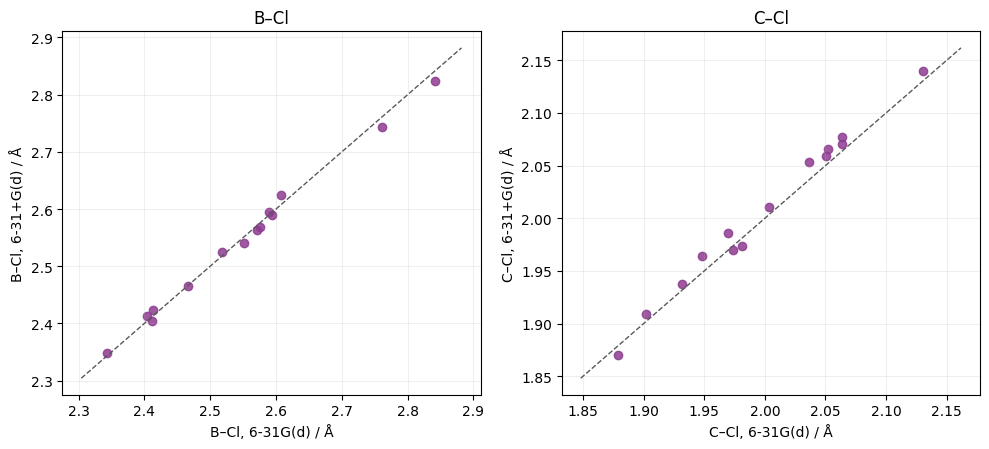

In [28]:
if comparison_df.empty:
    print("Figure deferred until at least one 6-31+G(d) output passes QC.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), gridspec_kw={"width_ratios": [1, 1]})
    plot_specs = [
        (axes[0], "B_Cl_631gd_A", "B_Cl_631plusgd_A", "B–Cl", "Å"),
        (axes[1], "C_Cl_631gd_A", "C_Cl_631plusgd_A", "C–Cl", "Å"),
        # (
        #     axes[2],
        #     "B_Cl_C_angle_631gd_deg",
        #     "B_Cl_C_angle_631plusgd_deg",
        #     "B–Cl–C angle",
        #     "deg",
        # ),
    ]
    for axis, x_column, y_column, label, unit in plot_specs:
        axis.scatter(comparison_df[x_column], comparison_df[y_column], color="#8d3c8f", alpha=0.85)
        lower = min(comparison_df[x_column].min(), comparison_df[y_column].min())
        upper = max(comparison_df[x_column].max(), comparison_df[y_column].max())
        padding = max((upper - lower) * 0.08, 0.005)
        axis.plot([lower - padding, upper + padding], [lower - padding, upper + padding], "--", color="0.35", lw=1)
        axis.set_xlabel(f"{label}, 6-31G(d) / {unit}")
        axis.set_ylabel(f"{label}, 6-31+G(d) / {unit}")
        axis.set_title(label)
        axis.grid(alpha=0.2)

    fig.tight_layout()
    figure_path = RESULT_DIR / "basis_set_bond_length_comparison.png"
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {figure_path}")
    plt.show()


In [ ]:
if comparison_df.empty:
    print("Whole-structure RMSD is unavailable until at least one 6-31+G(d) output passes QC.")
else:
    rmsd_columns = [
        "name", "all_atom_rmsd_A",
        "delta_B_Cl_A", "delta_C_Cl_A", "delta_B_Cl_C_angle_deg",
    ]
    rmsd_table = comparison_df[rmsd_columns].sort_values("all_atom_rmsd_A", ascending=False).reset_index(drop=True)
    rmsd_summary_df = pd.DataFrame([{
        "n": len(rmsd_table),
        "mean_all_atom_rmsd_A": rmsd_table["all_atom_rmsd_A"].mean(),
        "median_all_atom_rmsd_A": rmsd_table["all_atom_rmsd_A"].median(),
        "min_all_atom_rmsd_A": rmsd_table["all_atom_rmsd_A"].min(),
        "max_all_atom_rmsd_A": rmsd_table["all_atom_rmsd_A"].max(),
        "max_rmsd_system": rmsd_table.loc[0, "name"],
    }])

    rmsd_summary_df.to_csv(RESULT_DIR / "basis_set_geometry_rmsd_summary.csv", index=False)
    rmsd_table.to_csv(RESULT_DIR / "basis_set_geometry_rmsd_per_structure.csv", index=False)

    qualifier = "COMPLETE" if len(comparison_df) == len(source_records) else "PARTIAL"
    print(
        f"{qualifier} aligned all-atom RMSD analysis: "
        "RMSD is computed after centroid translation and Kabsch rotation."
    )
    display(rmsd_summary_df)
    display(rmsd_table)


PARTIAL aligned all-atom RMSD analysis: RMSD is computed after centroid translation and Kabsch rotation.


,n,mean_all_atom_rmsd_A,median_all_atom_rmsd_A,min_all_atom_rmsd_A,max_all_atom_rmsd_A,max_rmsd_system
0,14,0.210367,0.042515,0.015133,1.358958,B_00427_L_00072_Cl_00477


,name,all_atom_rmsd_A,delta_B_Cl_A,delta_C_Cl_A,delta_B_Cl_C_angle_deg
0,B_00427_L_00072_Cl_00477,1.358958,0.003519,0.006807,0.986723
1,B_00388_L_00001_Cl_00519,0.878648,-0.017650,0.015826,1.095686
2,B_00388_L_00072_Cl_00490,0.190674,0.010224,-0.003551,4.241728
3,B_00388_L_00069_Cl_00490,0.163812,0.009098,-0.008291,1.846015
4,B_00394_L_00046_Cl_00519,0.069697,-0.010335,0.016925,0.954337
5,B_00391_L_00069_Cl_00519,0.056014,0.000215,0.009837,0.344370
6,B_00391_L_00033_Cl_00477,0.046557,-0.007249,0.006909,-0.113314
7,B_00388_L_00001_Cl_00506,0.038474,-0.018288,0.016188,0.529254
8,B_00391_L_00033_Cl_00519,0.036740,-0.008752,0.013656,0.638486
9,B_00388_L_00072_Cl_00519,0.026619,0.005918,0.008193,-0.318854


In [2]:
from DFTStructureGenerator.borane_xat_workflow import SPE_DFT_calc
SPE_DFT_calc(
    target_dir = BENCHMARK_DIR,
    opt_name='OPT_6-31plusGd',
    eng_name='ENG_6-31plusGd',
    method=SPE_METHOD,
)

E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B_00401_L_00146_Cl_00443.log didn't run successful
E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B_00401_L_00146_Cl_00443.log is not a right TS for unreal freq num of -1


In [17]:
rf'E:\work\B_Cl_Nu\Sum\TS_ENG\{log_name}*.log'.replace("_L_", "_Nu_")

'E:\\work\\B_Cl_Nu\\Sum\\TS_ENG\\B_00388_Nu_00001_Cl_00475*.log'

,name,eng_log_file,reference_eng_log_file,energy_631gd_hartree,energy_631plusgd_hartree,signed_deviation_hartree,absolute_deviation_hartree,signed_deviation_kcal_mol,absolute_deviation_kcal_mol
0,B_00388_L_00001_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00388_Nu_00001_Cl...,-931.851369,-931.850671,0.000698,0.000698,0.438264,0.438264
1,B_00394_L_00046_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00394_Nu_00046_Cl...,-1237.838108,-1237.837427,0.000681,0.000681,0.427321,0.427321
2,B_00388_L_00001_Cl_00506,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00388_Nu_00001_Cl...,-818.540836,-818.540212,0.000623,0.000623,0.391199,0.391199
3,B_00427_L_00072_Cl_00477,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00427_Nu_00072_Cl...,-1991.139926,-1991.139394,0.000531,0.000531,0.333466,0.333466
4,B_00391_L_00033_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00391_Nu_00033_Cl...,-1178.873448,-1178.872942,0.000506,0.000506,0.317220,0.317220
5,B_00427_L_00046_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00427_Nu_00046_Cl...,-1123.512284,-1123.511795,0.000489,0.000489,0.306822,0.306822
6,B_00388_L_00072_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00388_Nu_00072_Cl...,-1454.364802,-1454.364412,0.000390,0.000390,0.244537,0.244537
7,B_00391_L_00069_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00391_Nu_00069_Cl...,-1294.648242,-1294.647906,0.000336,0.000336,0.210727,0.210727
8,B_00388_L_00001_Cl_00477,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00388_Nu_00001_Cl...,-1351.912444,-1351.912149,0.000295,0.000295,0.184937,0.184937
9,B_00388_L_00001_Cl_00475,E:\work\B_Cl_Nu\Benchmark_new\ENG_6-31plusGd\B...,E:\work\B_Cl_Nu\Sum\TS_ENG\B_00388_Nu_00001_Cl...,-777.978637,-777.978382,0.000255,0.000255,0.159928,0.159928


MAE: 0.23234810036586037
Max Deviation: 0.43826356997755056


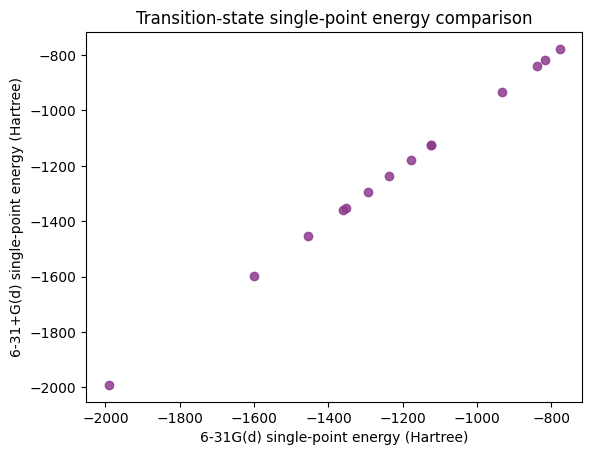

In [30]:
# Energy Analysis
energy_rows = []
for eng_log_file in glob.glob(str(ENG_BASIS_DIR / "*.log")):
    log_name = Path(eng_log_file).stem
    old_eng_log_file = glob.glob(
        rf"E:\work\B_Cl_Nu\Sum\TS_ENG\{log_name}*.log".replace("_L_", "_Nu_")
    )[0]
    eng_log = Logfile(str(eng_log_file), read_title=True, freq_warning=True, ignore_print=True)
    old_eng = Logfile(str(old_eng_log_file), read_title=True, freq_warning=True, ignore_print=True)

    before_energy = old_eng.all_engs[-1]
    after_energy = eng_log.all_engs[-1]
    signed_deviation_hartree = after_energy - before_energy

    energy_rows.append({
        "name": log_name,
        "eng_log_file": str(Path(eng_log_file)),
        "reference_eng_log_file": str(Path(old_eng_log_file)),
        "energy_631gd_hartree": before_energy,
        "energy_631plusgd_hartree": after_energy,
        "signed_deviation_hartree": signed_deviation_hartree,
        "absolute_deviation_hartree": abs(signed_deviation_hartree),
        "signed_deviation_kcal_mol": 627.5 * signed_deviation_hartree,
        "absolute_deviation_kcal_mol": 627.5 * abs(signed_deviation_hartree),
    })

energy_comparison_df = pd.DataFrame(energy_rows).sort_values(
    "absolute_deviation_kcal_mol", ascending=False
).reset_index(drop=True)
energy_comparison_df.to_csv(RESULT_DIR / "basis_set_energy_comparison.csv", index=False)
display(energy_comparison_df)

if energy_comparison_df.empty:
    print("No completed 6-31+G(d) single-point outputs yet; energy deviations cannot be evaluated.")
else:
    print("MAE:", energy_comparison_df["absolute_deviation_kcal_mol"].mean())
    print("Max Deviation:", energy_comparison_df["absolute_deviation_kcal_mol"].max())
    plt.scatter(
        energy_comparison_df["energy_631gd_hartree"],
        energy_comparison_df["energy_631plusgd_hartree"],
        color="#8d3c8f",
        alpha=0.85,
    )
    plt.xlabel("6-31G(d) single-point energy (Hartree)")
    plt.ylabel("6-31+G(d) single-point energy (Hartree)")
    plt.title("Transition-state single-point energy comparison")


## 6. Revision handoff

After all 15 calculations pass QC, report the mean signed change, mean absolute change, RMS change, and largest absolute change for both bonds plus the B–Cl–C angle from `basis_set_bond_length_summary.csv`. For the whole-structure comparison, report the mean/median/max aligned RMSD from `basis_set_geometry_rmsd_summary.csv`. The full per-structure tables provide traceability for the reviewer response. Any output with zero or multiple imaginary frequencies must be reoptimized or inspected before it is included.
